# 실습 9: 혼동행렬과 분류 결과 리포트
- 상황: 정확도 하나로는 어느 모델이 나은지 답할 수 없다
- 목표: 틀린 것을 두 종류로 나눠 보고, 오늘 결과를 리포트 한 장으로 마감한다

## Step 0. 앞 실습까지 재현하기

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. 불러오기
df = pd.read_csv("../../day02/lab06_clean-dataset/results/secom_clean.csv")

# 2. 센서 열 빈칸을 중앙값으로 채우기
sensor_cols = [c for c in df.columns if c != "result"]
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].median())

# 3. 불량여부 열 만들기
df["불량여부"] = (df["result"] == "불량").astype(int)

# 4. X, y 나누기
X = df[sensor_cols]
y = df["불량여부"]

# 5. 학습용·시험용 나누기
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 6. 로지스틱 회귀 - 단위를 맞춰야 하므로 표준화 (불균형 보정 설정 없이 기본 상태)
scaler = StandardScaler()
X_train_스케일 = scaler.fit_transform(X_train)
X_test_스케일 = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_스케일, y_train)
예측 = model.predict(X_test_스케일)

print("학습용 건수:", len(X_train))
print("시험용 건수:", len(X_test))
print("정확도:", round(accuracy_score(y_test, 예측) * 100, 2), "%")


학습용 건수: 1253
시험용 건수: 314
정확도: 93.95 %


## Step 1. 오늘 쓸 말 정리하기

### 용어 풀이 - 결과를 네 칸으로 나눠 볼 때 쓰는 말

| 말 | 뜻 |
|---|---|
| 혼동행렬 | 맞힌 것과 틀린 것을 네 칸으로 나눠 놓은 표 |
| 놓친 불량 | 불량인데 양품이라 한 것. 걸러지지 않고 고객에게 간다 |
| 헛경보 | 양품인데 불량이라 한 것. 멀쩡한 것을 세워 다시 본다 |
| 재현율 (recall) | 실제 불량 중 몇 %를 잡았나 |
| 정밀도 (precision) | 불량이라 한 것 중 진짜가 몇 %였나 |
| F1 | 재현율과 정밀도를 함께 보는 값. 한쪽만 좋으면 오르지 않는다 |

## Step 2. 네 칸으로 쪼개기

In [2]:
# confusion_matrix - 실제 답과 예측을 맞대어 네 칸으로 세어준다
from sklearn.metrics import confusion_matrix

행렬 = confusion_matrix(y_test, 예측)
print(행렬)

# ravel() - 네 칸을 한 줄로 펴서 하나씩 이름을 붙여 받는다
# 순서가 정해져 있다: 왼쪽위, 오른쪽위, 왼쪽아래, 오른쪽아래
맞힌양품, 헛경보, 놓친불량, 잡은불량 = 행렬.ravel()

print("양품인데 양품이라 함 :", 맞힌양품)
print("양품인데 불량이라 함 :", 헛경보,   " <- 헛경보")
print("불량인데 양품이라 함 :", 놓친불량, " <- 놓친 불량")
print("불량인데 불량이라 함 :", 잡은불량)

[[293   0]
 [ 19   2]]
양품인데 양품이라 함 : 293
양품인데 불량이라 함 : 0  <- 헛경보
불량인데 양품이라 함 : 19  <- 놓친 불량
불량인데 불량이라 함 : 2


## Step 3. 네 칸이 현장에서 무슨 상황인가

| 칸 | 내 숫자 | 현장에서는 |
|---|---|---|
| 양품인데 양품 | [293] | 아무 일 없음 |
| 양품인데 불량 (헛경보) | [0] | 멀쩡한 걸 세우고 다시 본다. 사람 손이 든다 |
| 불량인데 양품 (놓친 불량) | [19] | 걸러지지 않고 고객에게 간다 |
| 불량인데 불량 | [2] | 원하던 것. 미리 잡았다 |

## Step 4. 두 지표를 손으로 계산하기

In [3]:
# 재현율 - 실제 불량 중 몇 %를 잡았나
# 분모는 "실제 불량 전체" = 잡은 것 + 놓친 것
재현율 = 잡은불량 / (잡은불량 + 놓친불량)

# 정밀도 - 불량이라 한 것 중 진짜가 몇 %였나
# 분모는 "불량이라고 한 것 전체" = 진짜 + 헛경보
정밀도 = 잡은불량 / (잡은불량 + 헛경보)

print("재현율:", round(재현율, 3), " <- 실제 불량", 잡은불량 + 놓친불량, "건 중", 잡은불량, "건")
print("정밀도:", round(정밀도, 3), " <- 불량이라 한", 잡은불량 + 헛경보, "건 중", 잡은불량, "건")

재현율: 0.095  <- 실제 불량 21 건 중 2 건
정밀도: 1.0  <- 불량이라 한 2 건 중 2 건


### 문법 노트 - 네 칸에서 지표 뽑기

| 쓴 것 | 하는 일 | 왜 여기 쓰나 |
|---|---|---|
| confusion_matrix(실제, 예측) | 맞고 틀림을 네 칸으로 세어준다 | 정확도 하나로는 안 보이는 걸 본다 |
| .ravel() | 네 칸을 한 줄로 펴준다 | 칸마다 이름을 붙여 받으려고 |
| classification_report | 지표를 한 번에 계산해 표로 보여준다 | 손으로 구한 값과 맞춰보려고 |

**분자는 둘 다 같고 분모가 다르다.**<br>
재현율 = 잡은불량 / (잡은불량 + 놓친불량)   분모가 "실제 불량 전체"<br>
정밀도 = 잡은불량 / (잡은불량 + 헛경보)     분모가 "불량이라 한 것 전체"<br>
헷갈리면 분모부터 정하면 된다.

## Step 5. 라이브러리 출력과 대조하기

In [4]:
from sklearn.metrics import classification_report

# target_names - 0과 1 대신 사람이 읽을 이름을 붙인다
# digits=3 - 소수점 셋째 자리까지
print(classification_report(y_test, 예측,
                            target_names=["양품", "불량"], digits=3))

              precision    recall  f1-score   support

          양품      0.939     1.000     0.969       293
          불량      1.000     0.095     0.174        21

    accuracy                          0.939       314
   macro avg      0.970     0.548     0.571       314
weighted avg      0.943     0.939     0.915       314



## Step 6. 기준 모델의 재현율은 얼마인가

In [5]:
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

# 전부 양품(0)이라고만 답하는 기준 모델
기준예측 = np.zeros(len(y_test), dtype=int)

행목록 = []
for 이름, pred in [("기준 모델 (전부 양품)", 기준예측), ("로지스틱 회귀", 예측)]:
    정확도 = accuracy_score(y_test, pred) * 100
    # zero_division=0 — 불량이라 예측한 게 0건이면 정밀도(TP/(TP+FP))가 0/0이 되는데, 그럴 때 경고 대신 0으로 처리한다
    재현율 = recall_score(y_test, pred, zero_division=0) * 100
    정밀도 = precision_score(y_test, pred, zero_division=0) * 100
    f1 = f1_score(y_test, pred, zero_division=0) * 100
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    행목록.append({
        "모델": 이름,
        "정확도(%)": round(정확도, 2),
        "재현율(%)": round(재현율, 2),
        "정밀도(%)": round(정밀도, 2),
        "F1(%)": round(f1, 2),
        "놓친 불량(FN)": fn,
        "헛경보(FP)": fp,
    })

비교표 = pd.DataFrame(행목록)
비교표


,모델,정확도(%),재현율(%),정밀도(%),F1(%),놓친 불량(FN),헛경보(FP)
0,기준 모델 (전부 양품),93.31,0.00,0.0,0.00,21,0
1,로지스틱 회귀,93.95,9.52,100.0,17.39,19,0


### 결과 정리 (실행 결과 기준)

| 모델 | 정확도(%) | 재현율(%) | 정밀도(%) | F1(%) | 놓친 불량(FN) | 헛경보(FP) |
|---|---|---|---|---|---|---|
| 기준 모델 (전부 양품) | 93.31 | 0.0 | 0.0 | 0.0 | 21 | 0 |
| 로지스틱 회귀 | 93.95 | 9.52 | 100.0 | 17.39 | 19 | 0 |

기준 모델의 재현율은 **0%**다 — 불량이라고 한 번도 답하지 않았으니 실제 불량 21건 중 하나도 못 잡는다. 정밀도·F1도 같은 이유로 0이다. 로지스틱 회귀는 재현율이 9.52%로 올라 21건 중 2건을 잡았지만, 여전히 19건을 놓친다.

**정밀도 0으로 나누기 경고가 뜨는 이유**: 정밀도 = TP / (TP + FP)인데, 기준 모델처럼 불량이라 예측한 건수(TP+FP)가 0이면 분모가 0이 되어 계산이 안 되기 때문이다 — `zero_division=0`을 주면 그 경우 경고 대신 0으로 처리해준다.

## Step 7. 판정 문턱을 낮춰 더 잡아보기
모델을 다시 학습시키지 않고, 모델이 내놓는 "불량일 가능성" 확률에 문턱(0.5/0.3/0.2/0.1)만 다르게 적용해 비교한다. 기존 `예측`은 건드리지 않고 새 이름으로 만든다.

In [6]:
# predict_proba — 각 행이 불량(1)일 가능성을 0~1 확률로 내놓는다. 모델은 다시 학습시키지 않는다
확률 = model.predict_proba(X_test_스케일)[:, 1]

문턱결과 = []
for 문턱 in [0.5, 0.3, 0.2, 0.1]:
    # 확률이 문턱 이상이면 불량(1)으로 판정 — 새 이름으로 남긴다
    예측_문턱 = (확률 >= 문턱).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, 예측_문턱).ravel()
    재현율 = recall_score(y_test, 예측_문턱, zero_division=0) * 100
    정밀도 = precision_score(y_test, 예측_문턱, zero_division=0) * 100

    문턱결과.append({
        "문턱": 문턱,
        "잡은 불량(TP)": tp,
        "놓친 불량(FN)": fn,
        "헛경보(FP)": fp,
        "재현율(%)": round(재현율, 2),
        "정밀도(%)": round(정밀도, 2),
    })

문턱표 = pd.DataFrame(문턱결과)
문턱표


,문턱,잡은 불량(TP),놓친 불량(FN),헛경보(FP),재현율(%),정밀도(%)
0,0.5,2,19,0,9.52,100.00
1,0.3,3,18,6,14.29,33.33
2,0.2,5,16,13,23.81,27.78
3,0.1,9,12,42,42.86,17.65


### 결과 정리 (실행 결과 기준)

| 문턱 | 잡은 불량(TP) | 놓친 불량(FN) | 헛경보(FP) | 재현율(%) | 정밀도(%) |
|---|---|---|---|---|---|
| 0.5 | 2 | 19 | 0 | 9.52 | 100.0 |
| 0.3 | 3 | 18 | 6 | 14.29 | 33.33 |
| 0.2 | 5 | 16 | 13 | 23.81 | 27.78 |
| 0.1 | 9 | 12 | 42 | 42.86 | 17.65 |

문턱을 0.5→0.1로 낮출수록 재현율은 9.52%→42.86%로 올라가지만(더 많은 불량을 잡음), 그만큼 헛경보도 0건→42건으로 늘어나 정밀도는 100%→17.65%로 떨어진다. 재현율과 정밀도는 문턱을 낮추는 방향으로 함께 갈 수 없고 서로 맞바꿔야 하는 관계로 보인다.

### 문턱을 낮추면

| 문턱 | 잡은 불량 | 놓친 불량 | 헛경보 | 재현율 | 정밀도 |
|---|---|---|---|---|---|
| 0.5 | [2] | [19] | [0] | [0.095] | [1.000] |
| 0.3 | [3] | [18] | [6] | [0.143] | [0.333] |
| 0.2 | [5] | [16] | [13] | [0.238] | [0.278] |
| 0.1 | [9] | [12] | [42] | [0.429] | [0.176] |

## Step 8. 분류 결과 리포트 마감하기
이 노트북에서 이미 계산된 값(`행렬`, `비교표`, `문턱표` 등)을 그대로 읽어, 혼동행렬 그림과 `report.md`를 `results` 폴더에 저장한다.

정제본 행 수, 열 수: 1567 52
전체 불량 비율: 6.64 %


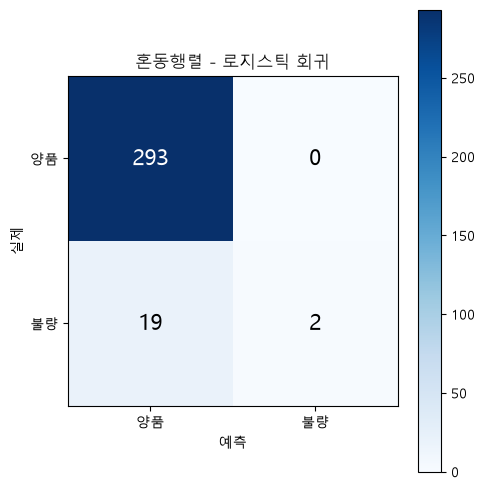

저장 완료: results/confusion_matrix.png, results/report.md


In [7]:
import os
import matplotlib.pyplot as plt

os.makedirs("results", exist_ok=True)

# 정제본 정보 — 이미 불러온 df에서 새로 계산 (아직 이 노트북에 출력된 적 없음)
정제본행수, 정제본열수 = df.shape
전체불량비율 = round(df["불량여부"].mean() * 100, 2)
print("정제본 행 수, 열 수:", 정제본행수, 정제본열수)
print("전체 불량 비율:", 전체불량비율, "%")

# (1) 혼동행렬 그림 — Step 2에서 이미 구한 '행렬'을 그대로 쓴다
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(행렬, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["양품", "불량"])
ax.set_yticklabels(["양품", "불량"])
ax.set_xlabel("예측")
ax.set_ylabel("실제")
ax.set_title("혼동행렬 - 로지스틱 회귀")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(행렬[i, j]), ha="center", va="center",
                color="white" if 행렬[i, j] > 행렬.max() / 2 else "black",
                fontsize=16)

fig.colorbar(im)
fig.tight_layout()
fig.savefig("results/confusion_matrix.png", dpi=150)
plt.show()

# (2) report.md — Step 6의 '비교표', Step 7의 '문턱표'를 그대로 쓴다
report = []
report.append("# 분류 결과 리포트\n")

report.append("## 1. 데이터\n")
report.append("| 항목 | 값 |")
report.append("|---|---|")
report.append(f"| 정제본 행 수 | {정제본행수} |")
report.append(f"| 정제본 열 수 | {정제본열수} |")
report.append(f"| 전체 불량 비율 | {전체불량비율}% |")
report.append(f"| 학습용 건수 | {len(X_train)} |")
report.append(f"| 시험용 건수 | {len(X_test)} |")
report.append("")

report.append("## 2. 모델\n")
report.append("| 항목 | 값 |")
report.append("|---|---|")
report.append("| 모델 이름 | LogisticRegression |")
report.append("| 함께 넣은 처리 | StandardScaler (표준화) |")
report.append("")

report.append("## 3. 결과 표\n")
report.append("| 모델 | 정확도(%) | 재현율(%) | 정밀도(%) | F1(%) |")
report.append("|---|---|---|---|---|")
for _, row in 비교표.iterrows():
    report.append(f"| {row['모델']} | {row['정확도(%)']} | {row['재현율(%)']} | {row['정밀도(%)']} | {row['F1(%)']} |")
report.append("")

report.append("## 4. 혼동행렬\n")
report.append("| 구분 | 예측: 양품 | 예측: 불량 |")
report.append("|---|---|---|")
report.append(f"| 실제: 양품 | {맞힌양품} | {헛경보} |")
report.append(f"| 실제: 불량 | {놓친불량} | {잡은불량} |")
report.append("")

report.append("## 5. 문턱별 비교표\n")
report.append("| 문턱 | 잡은 불량(TP) | 놓친 불량(FN) | 헛경보(FP) | 재현율(%) | 정밀도(%) |")
report.append("|---|---|---|---|---|---|")
for _, row in 문턱표.iterrows():
    report.append(f"| {row['문턱']} | {row['잡은 불량(TP)']} | {row['놓친 불량(FN)']} | {row['헛경보(FP)']} | {row['재현율(%)']} | {row['정밀도(%)']} |")
report.append("")

report.append("## 6. 그림 파일\n")
report.append("| 파일명 |")
report.append("|---|")
report.append("| confusion_matrix.png |")
report.append("")

with open("results/report.md", "w", encoding="utf-8") as f:
    f.write("\n".join(report))

print("저장 완료: results/confusion_matrix.png, results/report.md")


---
## 직접 해보기 (도전) - 다른 모델도 같은 문턱에서 같을까

- 상황: 한 모델로만 문턱을 옮겨봤다. 다른 모델도 같은 모양일지는 모른다
- 할 일: 앞 실습에서 추천받은 다른 모델로 같은 표를 만들어 나란히 놓는다
- 결과물: 두 모델 문턱 비교표 1개

In [9]:
from sklearn.tree import DecisionTreeClassifier

# 추천받았던 다른 모델 — 의사결정나무. 같은 X_train, y_train으로 학습 (스케일 안 맞춰도 됨)
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

확률_tree = tree_model.predict_proba(X_test)[:, 1]

tree_문턱결과 = []
for 문턱 in [0.5, 0.3, 0.2, 0.1]:
    예측_tree_문턱 = (확률_tree >= 문턱).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, 예측_tree_문턱).ravel()
    재현율 = recall_score(y_test, 예측_tree_문턱, zero_division=0) * 100
    정밀도 = precision_score(y_test, 예측_tree_문턱, zero_division=0) * 100

    tree_문턱결과.append({
        "문턱": 문턱,
        "잡은 불량(TP)": tp,
        "놓친 불량(FN)": fn,
        "헛경보(FP)": fp,
        "재현율(%)": round(재현율, 2),
        "정밀도(%)": round(정밀도, 2),
    })

tree_문턱표 = pd.DataFrame(tree_문턱결과)
print("[의사결정나무] 문턱별 비교")
display(tree_문턱표)

print()
print("[로지스틱 회귀] 문턱별 비교 (앞에서 만든 표, 그대로)")
display(문턱표)


[의사결정나무] 문턱별 비교


,문턱,잡은 불량(TP),놓친 불량(FN),헛경보(FP),재현율(%),정밀도(%)
0,0.5,5,16,26,23.81,16.13
1,0.3,5,16,26,23.81,16.13
2,0.2,5,16,26,23.81,16.13
3,0.1,5,16,26,23.81,16.13



[로지스틱 회귀] 문턱별 비교 (앞에서 만든 표, 그대로)


,문턱,잡은 불량(TP),놓친 불량(FN),헛경보(FP),재현율(%),정밀도(%)
0,0.5,2,19,0,9.52,100.00
1,0.3,3,18,6,14.29,33.33
2,0.2,5,16,13,23.81,27.78
3,0.1,9,12,42,42.86,17.65


### 결과 정리 (실행 결과 기준)

**[의사결정나무] 문턱별 비교**

| 문턱 | 잡은 불량(TP) | 놓친 불량(FN) | 헛경보(FP) | 재현율(%) | 정밀도(%) |
|---|---|---|---|---|---|
| 0.5 | 5 | 16 | 26 | 23.81 | 16.13 |
| 0.3 | 5 | 16 | 26 | 23.81 | 16.13 |
| 0.2 | 5 | 16 | 26 | 23.81 | 16.13 |
| 0.1 | 5 | 16 | 26 | 23.81 | 16.13 |

**[로지스틱 회귀] 문턱별 비교 (앞서 만든 표)**

| 문턱 | 잡은 불량(TP) | 놓친 불량(FN) | 헛경보(FP) | 재현율(%) | 정밀도(%) |
|---|---|---|---|---|---|
| 0.5 | 2 | 19 | 0 | 9.52 | 100.0 |
| 0.3 | 3 | 18 | 6 | 14.29 | 33.33 |
| 0.2 | 5 | 16 | 13 | 23.81 | 27.78 |
| 0.1 | 9 | 12 | 42 | 42.86 | 17.65 |

의사결정나무는 문턱을 0.5→0.1로 낮춰도 결과가 전혀 바뀌지 않는다 — 확인해보니 `확률_tree` 값이 0.0 아니면 1.0뿐이다(잎이 순수해질 때까지 나눈 기본 설정이라, 0.1~0.9 사이 확률 자체가 안 나온다). 반면 로지스틱 회귀는 문턱을 낮출수록 재현율과 헛경보가 함께 늘어난다. 같은 문턱 0.5에서는 의사결정나무(재현율 23.81%)가 로지스틱 회귀(재현율 9.52%)보다 더 많이 잡지만, 헛경보도 훨씬 많다(26건 vs 0건).